In [108]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from matplotlib.lines import Line2D

In [103]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[3:4] + ["goldenrod"]
color_list2 = ["DodgerBlue", "purple"]

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [5]:
h0 = 0.6774

In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [7]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12
<class 'dict'>


In [63]:
group_sfrs = halos["GroupSFR"]

In [8]:
gal_sfrs = subhalos["SubhaloSFR"]

In [15]:
gal_mvir = mvir[subhalos["SubhaloGrNr"]]

In [ ]:
sfr_lim = 1.6

In [69]:
mask = (np.log10(gal_sfrs) > sfr_lim) & (gal_mvir > 10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [70]:
gal_shot = ps.compute_shotnoise(gal_sfrs[mask], boxsize=205, weighting = 1)

In [71]:
gal_groupids = subhalos["SubhaloGrNr"][mask]

In [72]:
unique_ids, indices, counts = np.unique(gal_groupids, return_index=True, return_counts=True)

In [56]:
group_shot = ps.compute_shotnoise(counts, boxsize=205, weighting = 1)

In [77]:
group_shot/gal_shot

1.1018005540166205

In [122]:
sfr_lim = 1
mask = (np.log10(gal_sfrs) > sfr_lim) & (gal_mvir > 10)
gal_shot1 = ps.compute_shotnoise(gal_sfrs[mask], boxsize=205, weighting = 1)
gal_groupids = subhalos["SubhaloGrNr"][mask]
unique_ids, indices, counts = np.unique(gal_groupids, return_index=True, return_counts=True)
group_shot1 = ps.compute_shotnoise(counts, boxsize=205, weighting = 1)
group_shot1/gal_shot1

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


1.2469456847063443

In [123]:
sfr_lim = 1.6
mask = (np.log10(gal_sfrs) > sfr_lim) & (gal_mvir > 10)
gal_shot16 = ps.compute_shotnoise(gal_sfrs[mask], boxsize=205, weighting = 1)
gal_groupids = subhalos["SubhaloGrNr"][mask]
unique_ids, indices, counts = np.unique(gal_groupids, return_index=True, return_counts=True)
group_shot16 = ps.compute_shotnoise(counts, boxsize=205, weighting = 1)
group_shot16/gal_shot16

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


1.1018005540166205

In [66]:
lim_gal_shot = ps.compute_shotnoise(gal_sfrs, boxsize=205, weighting = "LIM")

In [67]:
lim_group_shot = ps.compute_shotnoise(group_sfrs, boxsize=205, weighting = "LIM")

In [76]:
lim_group_shot/lim_gal_shot

2.3323115245502244

In [88]:

odir = "../ps_data"
group_dir="gal"
sfr_lim=1

with open(f"{odir}/snap40/mvir/gal_survey/logSFR{sfr_lim}/{group_dir}/logMmin10.pickle", "rb") as f:
    Pk_mean1 = pickle.load(f)
    Pk1 = pickle.load(f)

In [89]:

odir = "../ps_data"
group_dir="gal"
sfr_lim=1.6

with open(f"{odir}/snap40/mvir/gal_survey/logSFR{sfr_lim}/{group_dir}/logMmin10.pickle", "rb") as f:
    Pk_mean16 = pickle.load(f)
    Pk16 = pickle.load(f)

In [86]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [106]:

#odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [ ]:
Pk1

In [119]:
group_shot1/Pk1["power"].real[0]

0.029950960949844604

In [124]:
gal_shot1/Pk1["power"].real[0]

0.024019459161044417

In [120]:
group_shot16/Pk16["power"].real[0]

0.2646395531637262

In [128]:
gal_shot16/Pk16["power"].real[0]

0.24018825566839766

In [121]:
Pk_sum10.attrs["shotnoise"]/Pk_gal10["power"].real[0]

0.027112634504095415

In [127]:
Pk_gal10.attrs["shotnoise"]/Pk_gal10["power"].real[0]

0.011637457162851934

In [100]:
ks = Pk1["k"]
coef = Pk1["k"]**3/(2*np.pi**2)
len_k=len(ks)

shotnoise:  130.52360745197086
shotnoise:  338.99130400566617
shotnoise:  5414.9120050282845


UnboundLocalError: local variable 'frame1' referenced before assignment

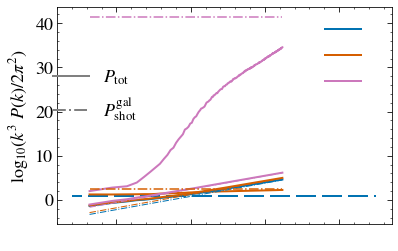

In [96]:
fig,ax = plt.subplots()
ps.compare_ps_plot([Pk_gal10, Pk1, Pk16], create_fig=False, ax=ax)
ax.plot(np.log10(k), np.log10(coef*lim_group_shot))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:28: RuntimeWarning: invalid value encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:29: RuntimeWarning: invalid value encountered in log10


(0.97, 1.03)

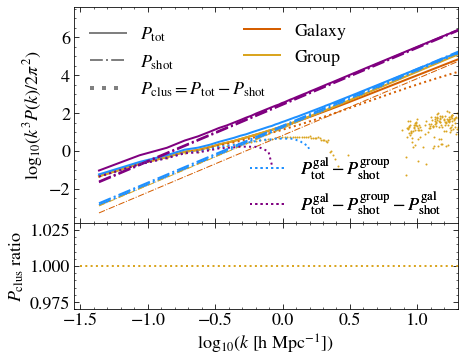

In [117]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10["power"].real)[:len_k], label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10["power"].real)[:len_k], label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * (Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"]))[:len_k], linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.scatter(np.log10(ks[:len_k]), np.log10(coef * (Pk_sum10["power"].real- Pk_sum10.attrs["shotnoise"]))[:len_k], label="TNG clustering (group)", color=color_list1[1], s=1)


plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk1["power"].real)[:len_k], label="TNG total", color=color_list2[0])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk16["power"].real)[:len_k], label="TNG total", color=color_list2[1])

plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk1.attrs["shotnoise"])[:len_k], label="TNG total", color=color_list2[0], linestyle="dashdot")
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk16.attrs["shotnoise"])[:len_k], label="TNG total", color=color_list2[1], linestyle="dashdot")

plt.plot(np.log10(ks[:len_k]), np.log10(coef * group_shot1)[:len_k], label="TNG total", color=color_list2[0], linestyle="dashdot")
plt.plot(np.log10(ks[:len_k]), np.log10(coef * group_shot16)[:len_k], label="TNG total", color=color_list2[1], linestyle="dashdot")




plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[0], linewidth=1)
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[1], linewidth=1)



plt.plot(np.log10(ks[:len_k]), np.log10(coef *(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"]))[:len_k], label="Subtract shotnoise", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks[:len_k]), np.log10(coef *(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"] - Pk_gal10.attrs["shotnoise"]))[:len_k], label="Subtract shotnoise", color = color_list2[1], linestyle="dotted")

#plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["Galaxy", "Group"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False, loc="upper left", bbox_to_anchor=(0.4,1))
ax.add_artist(first_legend)


color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}} = P_{\rm tot} - P_{\rm shot}$", linewidth=4)
shot_ps_leg = Line2D([],[],color=color, label=r"$P_{\mathrm{shot}}$", linewidth=2, linestyle="dashdot")

leg_list = [total_ps_leg, shot_ps_leg, shotnoise_subtracted_ps_leg]
leg = ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)
ax.add_artist(leg)
plt.xlim(-1.55,1.3)
plt.xticks(color="w")

label_list = [r"$P_{\rm tot}^{\rm gal} - P_{\rm shot}^{\rm group}$", r"$P_{\rm tot}^{\rm gal} - P_{\rm shot}^{\rm group} -  P_{\rm shot}^{\rm gal}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,-0.05))
ax.add_artist(second_legend)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([-1.5,np.log10(ks[-1])],[1,1],  color=color_list1[1], linestyle="dotted")

#plt.plot(np.log10(ks[:len_k]), (Pk_gal10["power"].real/Pk_gal10["power"].real)[:len_k])
iend = 15
# plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_gal10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list1[0])

# plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list2[0])
# plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"] - Pk_gal10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list2[1])

#plt.plot(np.log10(ks), coef * Pk_gal10["power"]/(pkgal2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
#plt.plot(np.log10(ks),coef * (Pk_gal10["power"]-Pk_gal10.attrs["shotnoise"])/(pkgal2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
#plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dotted")




plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
#plt.ylim(0.9,2.5)
#plt.ylabel(r"$\rm \dfrac{gal - group}{group - group}$", fontsize=16)
plt.ylabel(r"$P_{\mathrm{clus}}$ ratio")
#plt.savefig("figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")
plt.xlim(-1.55,1.3)
plt.ylim(0.97, 1.03)
#plt.savefig("../figures/one_halo_term_w_gal.pdf", format="pdf", bbox_inches="tight")